In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

from pathlib import Path
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
gdf = gpd.read_file(BASE_DIR / 'data' / 'processed' / 'combined_data.gpkg')

In [39]:
print(gdf.shape) 
gdf.info()

(8131, 41)
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8131 entries, 0 to 8130
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   objectid                    8131 non-null   int64   
 1   natcode                     8131 non-null   str     
 2   nombre                      8131 non-null   str     
 3   cod_nut1                    8131 non-null   str     
 4   cod_nut2                    8131 non-null   str     
 5   cod_nut3                    8131 non-null   str     
 6   codmun_ine                  8131 non-null   str     
 7   ccaa                        8131 non-null   str     
 8   cod_ccaa                    8131 non-null   str     
 9   cod_pro                     8131 non-null   str     
 10  provincia                   8131 non-null   str     
 11  pob_npmun                   8131 non-null   float64 
 12  pob_23                      8131 non-null   int64   
 13 

In [40]:
# Check for exact duplicate rows
print(f"Duplicates: {gdf.duplicated().sum()}")

Duplicates: 0


In [41]:
# Preview the data
display(gdf.head())

,objectid,natcode,nombre,cod_nut1,cod_nut2,cod_nut3,codmun_ine,ccaa,cod_ccaa,cod_pro,...,Total censo electoral_2019,PP_2019,PSOE_2019,VOX_2019,SUMAR_2019,PP_diff_2023_2019,PSOE_diff_2023_2019,VOX_diff_2023_2019,SUMAR_diff_2023_2019,geometry
0,7732,34160101001,Alegría-Dulantzi,ES2,ES21,ES211,01001,País Vasco-Euskadi,16,01,...,2020,5.643564,14.059406,2.673267,12.326733,1.102847,3.548250,0.436781,-4.288455,"MULTIPOLYGON (((-2.52642 42.83195, -2.52663 42..."
1,7733,34160101002,Amurrio,ES2,ES21,ES211,01002,País Vasco-Euskadi,16,01,...,8014,4.217619,11.604692,1.921637,10.806089,0.670313,4.730625,-0.250116,-3.550169,"MULTIPOLYGON (((-3.01619 43.04059, -3.01575 43..."
2,7737,34160101003,Aramaio,ES2,ES21,ES211,01003,País Vasco-Euskadi,16,01,...,1166,0.257290,2.229846,0.428816,6.689537,-0.083377,2.552763,0.005966,-0.776493,"MULTIPOLYGON (((-2.66113 43.06576, -2.66102 43..."
3,7738,34160101004,Artziniega,ES2,ES21,ES211,01004,País Vasco-Euskadi,16,01,...,1357,6.190125,7.958732,2.431835,10.832719,1.177543,6.061296,-0.071320,-2.964336,"MULTIPOLYGON (((-3.14189 43.16115, -3.14159 43..."
4,7734,34160101006,Armiñón,ES2,ES21,ES211,01006,País Vasco-Euskadi,16,01,...,174,12.068966,11.494253,10.344828,16.091954,4.687791,3.640882,-2.236719,-5.821684,"MULTIPOLYGON (((-2.8803 42.69937, -2.87852 42...."


In [42]:
display(gdf.describe())

,objectid,pob_npmun,pob_23,dens_pob,edad_media,afi_1000,paro_1000,porc_pob65,pob_esup16,porc_pob_e,...,SUMAR_2023,Total censo electoral_2019,PP_2019,PSOE_2019,VOX_2019,SUMAR_2019,PP_diff_2023_2019,PSOE_diff_2023_2019,VOX_diff_2023_2019,SUMAR_diff_2023_2019
count,8131.000000,8131.000000,8.131000e+03,8131.000000,8131.000000,8131.000000,8131.000000,8131.000000,8131.000000,8131.000000,...,8131.000000,8.131000e+03,8131.000000,8131.000000,8131.000000,8131.000000,8131.000000,8131.000000,8131.000000,8131.000000
mean,4066.000000,42.461398,5.906102e+03,181.957331,50.514407,443.706193,69.123723,29.406068,22.825241,7.244836,...,6.184236,4.288602e+03,19.262758,20.326309,10.027754,6.908329,7.987868,2.406901,-0.776025,-0.724092
std,2347.361853,16.661149,4.832552e+04,931.001505,6.625279,343.985279,42.936489,10.944929,10.972519,7.619648,...,4.610202,3.461099e+04,12.037222,9.704329,6.185374,5.184049,5.826524,4.890986,3.765361,2.983825
min,1.000000,0.000000,3.000000e+00,0.233938,34.660000,0.000000,0.000000,5.274262,0.000000,0.000000,...,0.000000,3.000000e+00,0.000000,0.000000,0.000000,0.000000,-37.142857,-46.666667,-55.555556,-33.746130
25%,2033.500000,30.658466,1.540000e+02,4.648312,45.120000,279.292712,40.276408,20.871090,16.279070,2.105263,...,3.125000,1.340000e+02,11.550711,13.809008,5.263158,3.370787,4.094675,-0.284855,-2.554178,-2.116982
50%,4066.000000,42.622951,5.300000e+02,13.438741,49.800000,381.348274,64.734300,27.956989,22.072072,4.958678,...,5.300353,4.330000e+02,18.535127,20.036680,9.876366,5.769231,8.353458,2.087446,-0.669363,-0.760104
75%,6098.500000,54.197139,2.435500e+03,56.628742,55.410000,507.089040,92.075530,36.666667,29.337688,10.091743,...,8.116226,1.827500e+03,26.440851,26.363304,13.913043,9.334737,11.402764,5.105483,0.925751,0.504864
max,8131.000000,94.444444,3.332035e+06,27807.942910,75.120000,7293.241695,1000.000000,80.000000,63.414634,88.607595,...,61.111111,2.384269e+06,93.750000,80.000000,55.555556,55.405405,46.464646,38.888889,33.333333,33.333333


In [43]:
display(gdf.describe(include=['object']))

C:\Users\rodri\AppData\Local\Temp\ipykernel_19400\2076970972.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(gdf.describe(include=['object']))


,natcode,nombre,cod_nut1,cod_nut2,cod_nut3,codmun_ine,ccaa,cod_ccaa,cod_pro,provincia
count,8131,8131,8131,8131,8131,8131,8131,8131,8131,8131
unique,8131,8114,7,19,59,8131,19,19,52,52
top,34160101001,Sancti-Spíritus,ES4,ES41,ES412,01001,Castilla y León,07,09,Burgos
freq,1,2,3555,2248,371,1,2248,2248,371,371


# Mean Net Income Distribution

In [89]:
def plot_univariate_distribution(df, column, title=None, xlabel=None, color='steelblue', bins=50):
        """
        Plots an histogram with Mean and IQR annotations.
        
        Parameters:
        - df: The (Geo)DataFrame containing the data.
        - column: The string name of the column to plot.
        - title: Custom title (optional).
        - xlabel: Custom x-axis label (optional).
        - color: Color of the histogram.
        - bins: Number of bins for the histogram.
        """
        
        print(gdf[column].describe())

        # Clean data for calculation (remove NaNs)
        data = df[column].dropna()
        
        # Calculate Statistics
        mean_val = data.mean()
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        data_range = data.max() - data.min()
        
        # Create the Figure
        plt.figure(figsize=(10, 6))
        sns.set_theme(style="white")
        
        # Draw the Plot
        sns.histplot(
                data=df, 
                x=column, 
                bins=bins, 
                kde=True,
                color=color,
                edgecolor='white',
                alpha=0.7
        )
        
        # Add Mean line and Tag
        plt.axvline(mean_val, color='black', linestyle='--', linewidth=1.5)
        
        # We use 2% of the data range as a dynamic offset for the text
        text_offset = data_range * 0.02 
        
        plt.text(
                x=mean_val + text_offset, 
                y=plt.ylim()[1] * 0.9, 
                s=f'MEAN\n{mean_val:,.2f}',
                fontsize=10,
                fontweight='bold',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha=0.8)
        )
        
        # Add IQR span and Tag
        plt.axvspan(q1, q3, color='gray', alpha=0.15)
        
        plt.text(
                x=(q1 + q3) / 2, 
                y=plt.ylim()[1] * 0.02, 
                s=f'IQR: {q1:,.1f} - {q3:,.1f}',
                fontsize=9,
                fontstyle='italic',
                color='black',
                ha='center'
        )
        
        # Labels and Polish
        plt.title(title if title else f'Distribution of {column}', fontsize=15, pad=20, fontweight='bold')
        plt.xlabel(xlabel if xlabel else column, fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        
        sns.despine()
        plt.tight_layout()
        
        return plt.show()

count     8131.000000
mean     27933.747878
std       6594.913623
min          0.000000
25%      23277.000000
50%      27074.000000
75%      30992.000000
max      83377.000000
Name: rta_nt_med, dtype: float64


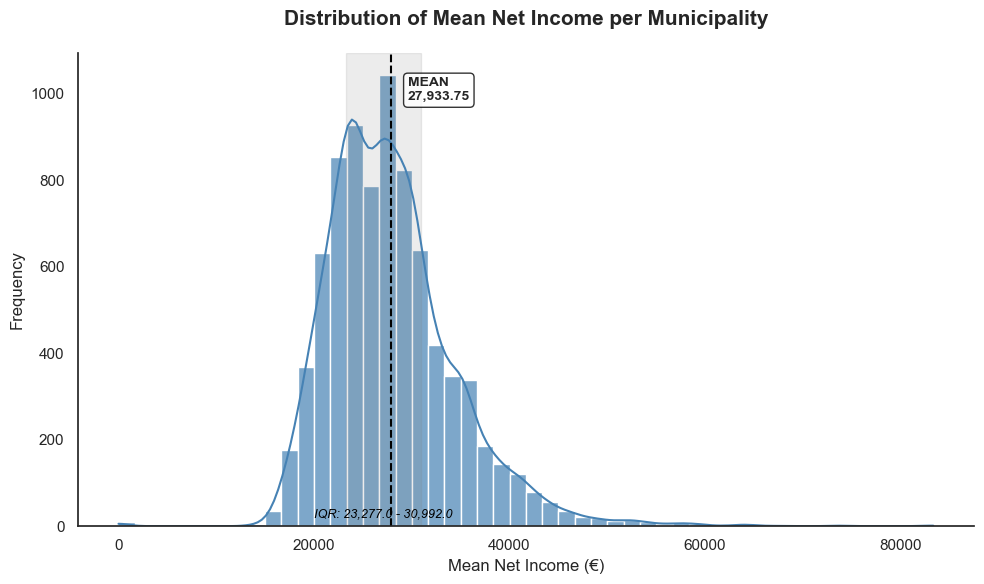

In [90]:
plot_univariate_distribution(gdf, 'rta_nt_med', title='Distribution of Mean Net Income per Municipality', xlabel='Mean Net Income (€)')

count    8131.000000
mean       50.514407
std         6.625279
min        34.660000
25%        45.120000
50%        49.800000
75%        55.410000
max        75.120000
Name: edad_media, dtype: float64


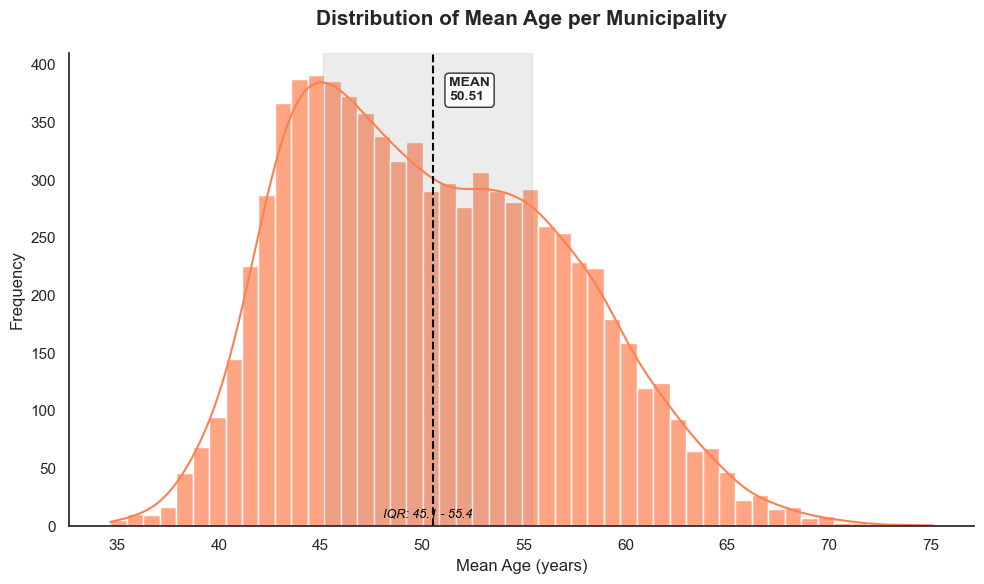

In [91]:
plot_univariate_distribution(gdf, 'edad_media', title='Distribution of Mean Age per Municipality', xlabel='Mean Age (years)', color='coral')

count    8131.000000
mean        7.244836
std         7.619648
min         0.000000
25%         2.105263
50%         4.958678
75%        10.091743
max        88.607595
Name: porc_pob_e, dtype: float64


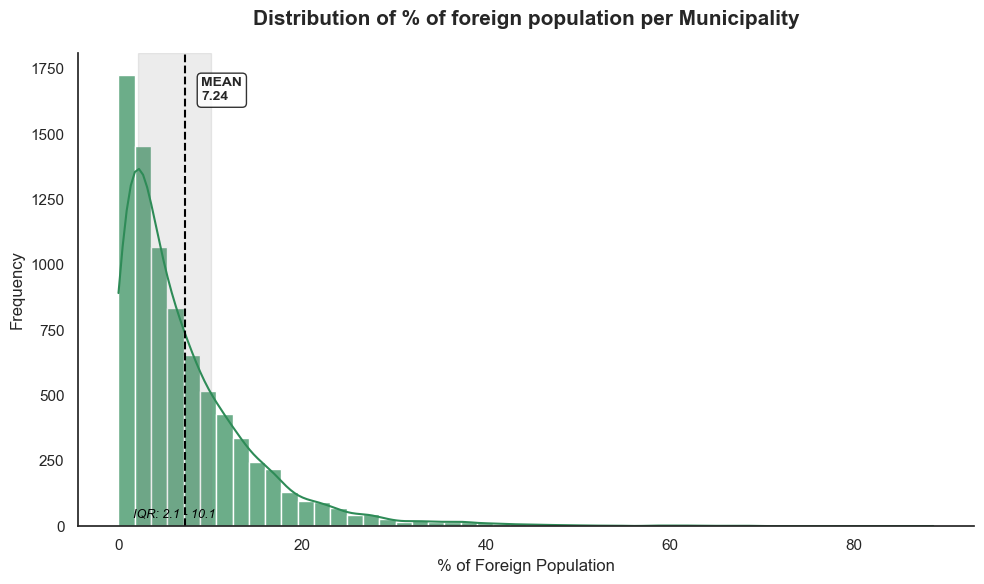

In [92]:
plot_univariate_distribution(gdf, 'porc_pob_e', title='Distribution of % of foreign population per Municipality', xlabel='% of Foreign Population', color='seagreen')

count    8131.000000
mean       22.825241
std        10.972519
min         0.000000
25%        16.279070
50%        22.072072
75%        29.337688
max        63.414634
Name: pob_esup16, dtype: float64


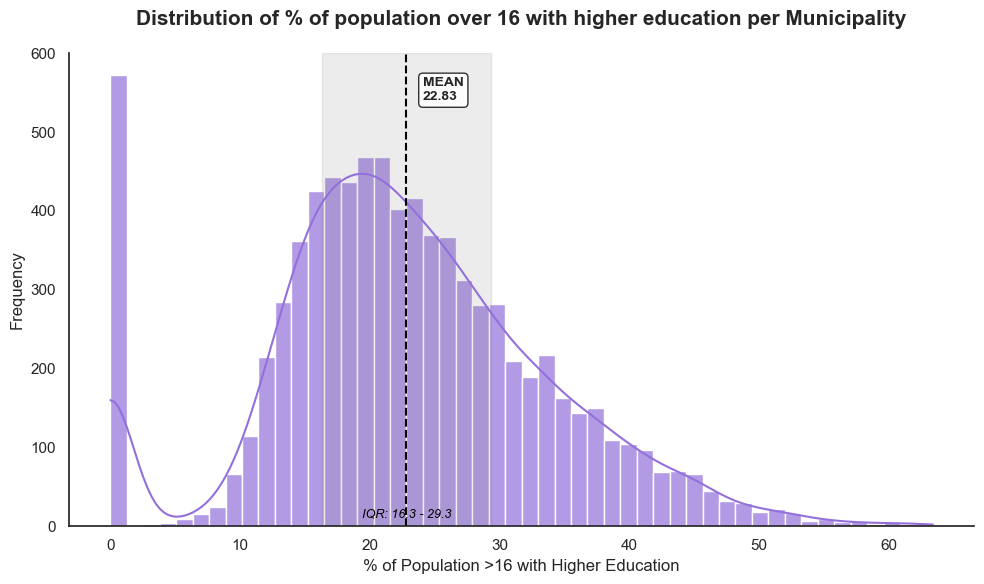

In [93]:
plot_univariate_distribution(gdf, 'pob_esup16', title='Distribution of % of population over 16 with higher education per Municipality', xlabel='% of Population >16 with Higher Education', color='mediumpurple')

count    8131.000000
mean      443.706193
std       343.985279
min         0.000000
25%       279.292712
50%       381.348274
75%       507.089040
max      7293.241695
Name: afi_1000, dtype: float64


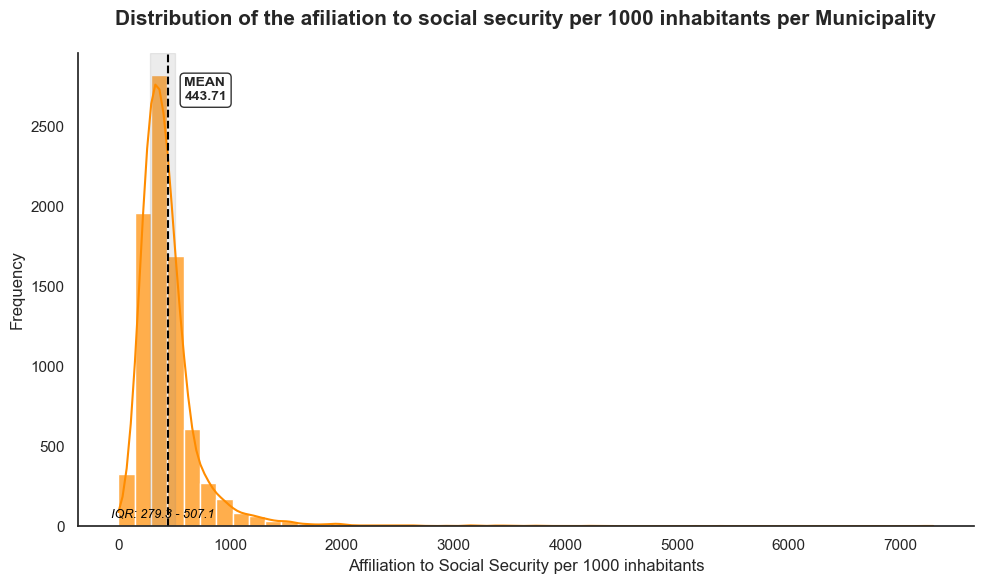

In [94]:
plot_univariate_distribution(gdf, 'afi_1000', title='Distribution of the afiliation to social security per 1000 inhabitants per Municipality', xlabel='Affiliation to Social Security per 1000 inhabitants', color='darkorange')

count    8131.000000
mean       69.123723
std        42.936489
min         0.000000
25%        40.276408
50%        64.734300
75%        92.075530
max      1000.000000
Name: paro_1000, dtype: float64


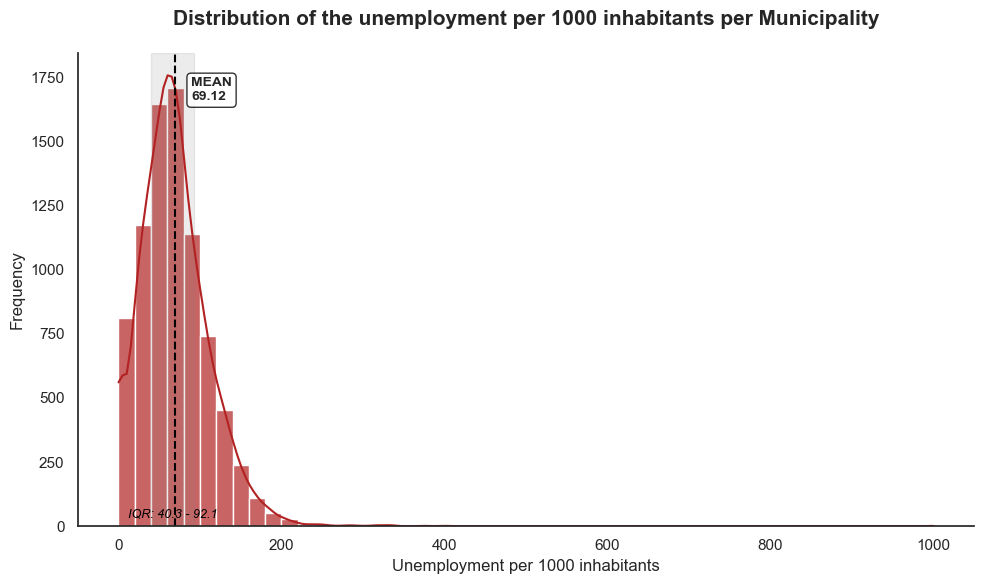

In [95]:
plot_univariate_distribution(gdf, 'paro_1000', title='Distribution of the unemployment per 1000 inhabitants per Municipality', xlabel='Unemployment per 1000 inhabitants', color='firebrick')

C:\Users\rodri\AppData\Local\Temp\ipykernel_19400\659182213.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


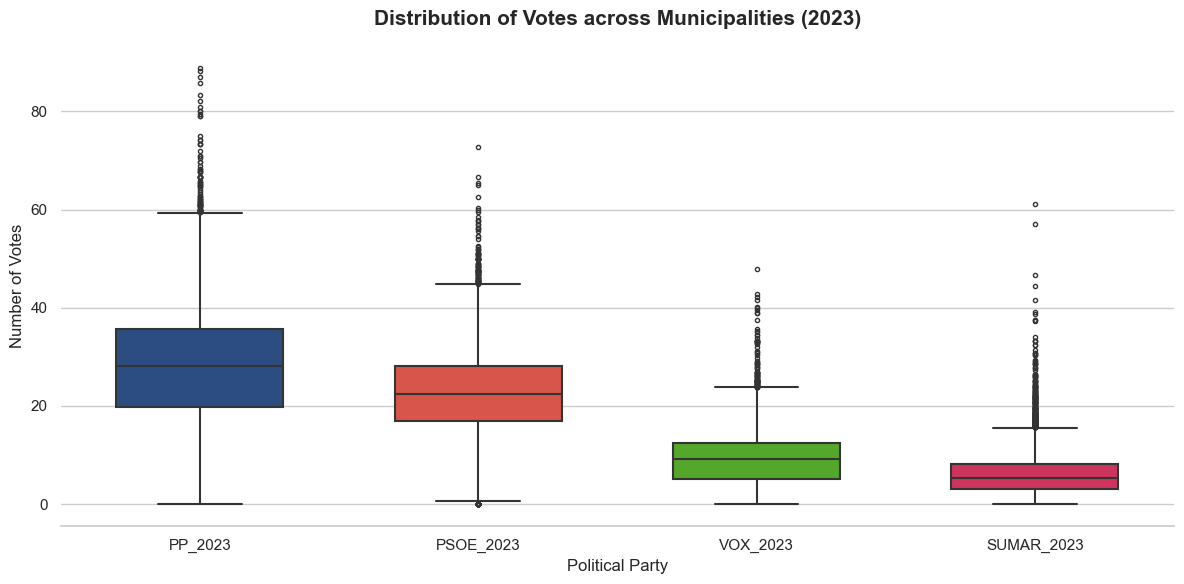

In [96]:
# List of parties to include
parties = ["PP_2023", "PSOE_2023", "VOX_2023", "SUMAR_2023"]

# Melt for the boxplot
df_long = gdf.melt(
    id_vars=[JOING_KEY_MITECO], # Keep municipality name for reference
    value_vars=parties, 
    var_name='Party', 
    value_name='Votes'
)

# Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Define palette from your config
# Ensure the keys in COLOURS_PARTIES match the 'Party' labels in df_long
palette = {p: COLOURS_PARTIES.get(p, COLOURS_PARTIES.get(p.split('_')[0], 'gray')) 
           for p in parties}

# Create the boxplot
ax = sns.boxplot(
    data=df_long, 
    x='Party', 
    y='Votes', 
    palette=palette,
    width=0.6,
    fliersize=3,      # Size of the outlier points
    linewidth=1.5
)

# Add title and labels
plt.title('Distribution of Votes across Municipalities (2023)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Political Party', fontsize=12)
plt.ylabel('Number of Votes', fontsize=12)

sns.despine(left=True) # Remove left border for a cleaner look
plt.tight_layout()
plt.show()

In [100]:
def plot_party_comparison(df, target_col, parties=None, colors_dict=COLOURS_PARTIES, 
                          calculate_pct=True, log_scale=False, flip_axes=False):
    """
    General function to correlate political support/swing with any demographic variable.
    """
    if parties is None:
        parties = ["PP_2023", "PSOE_2023", "VOX_2023", "SUMAR_2023"]
    
    # 1. Prepare Data
    plot_df = df.copy()
    
    # Optional: Calculate relative vote share (%)
    if calculate_pct:
        total_votes = plot_df[parties].sum(axis=1)
        for party in parties:
            plot_df[f'{party}_pct'] = (plot_df[party] / total_votes) * 100
        cols_to_plot = [f'{party}_pct' for party in parties]
    else:
        cols_to_plot = parties

    # 2. Setup Figure
    fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=not flip_axes, sharey=flip_axes)
    axes = axes.flatten()

    for i, party_col in enumerate(cols_to_plot):
        ax = axes[i]
        
        # Determine X and Y based on flip request
        x = target_col if not flip_axes else party_col
        y = party_col if not flip_axes else target_col
        
        # Determine Color
        base_name = parties[i].split('_')[0]
        color = colors_dict.get(parties[i], colors_dict.get(base_name, 'gray')) if colors_dict else 'steelblue'
        
        # Data cleaning for log scale (remove non-positive values)
        temp_df = plot_df[[x, y]].dropna()
        if log_scale:
            temp_df = temp_df[(temp_df[x] > 0) & (temp_df[y] > 0)]

        # 3. Plot
        sns.regplot(
            data=temp_df, x=x, y=y, ax=ax, color=color,
            logx=log_scale and not flip_axes,
            scatter_kws={'alpha': 0.1, 's': 5},
            line_kws={'color': 'black', 'linestyle': '--'}
        )
        
        # 4. Axes & Scales
        if log_scale:
            if flip_axes: ax.set_yscale('log')
            else: ax.set_xscale('log')

        # 5. Correlation Calculation
        corr = temp_df[[x, y]].corr().iloc[0, 1]
        
        # Titles
        title_subject = parties[i].replace('_', ' ')
        ax.set_title(f'{title_subject} vs {target_col.replace("_", " ")}', fontweight='bold', color=color)
        ax.text(0.95, 0.05, f'r = {corr:.2f}', transform=ax.transAxes, ha='right', 
                fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))
        
        ax.grid(True, linestyle=':', alpha=0.4)

    plt.suptitle(f'Analysis: {target_col} and Political Outcomes', fontsize=18, y=0.98, fontweight='bold')
    sns.despine()
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    return plt.show()

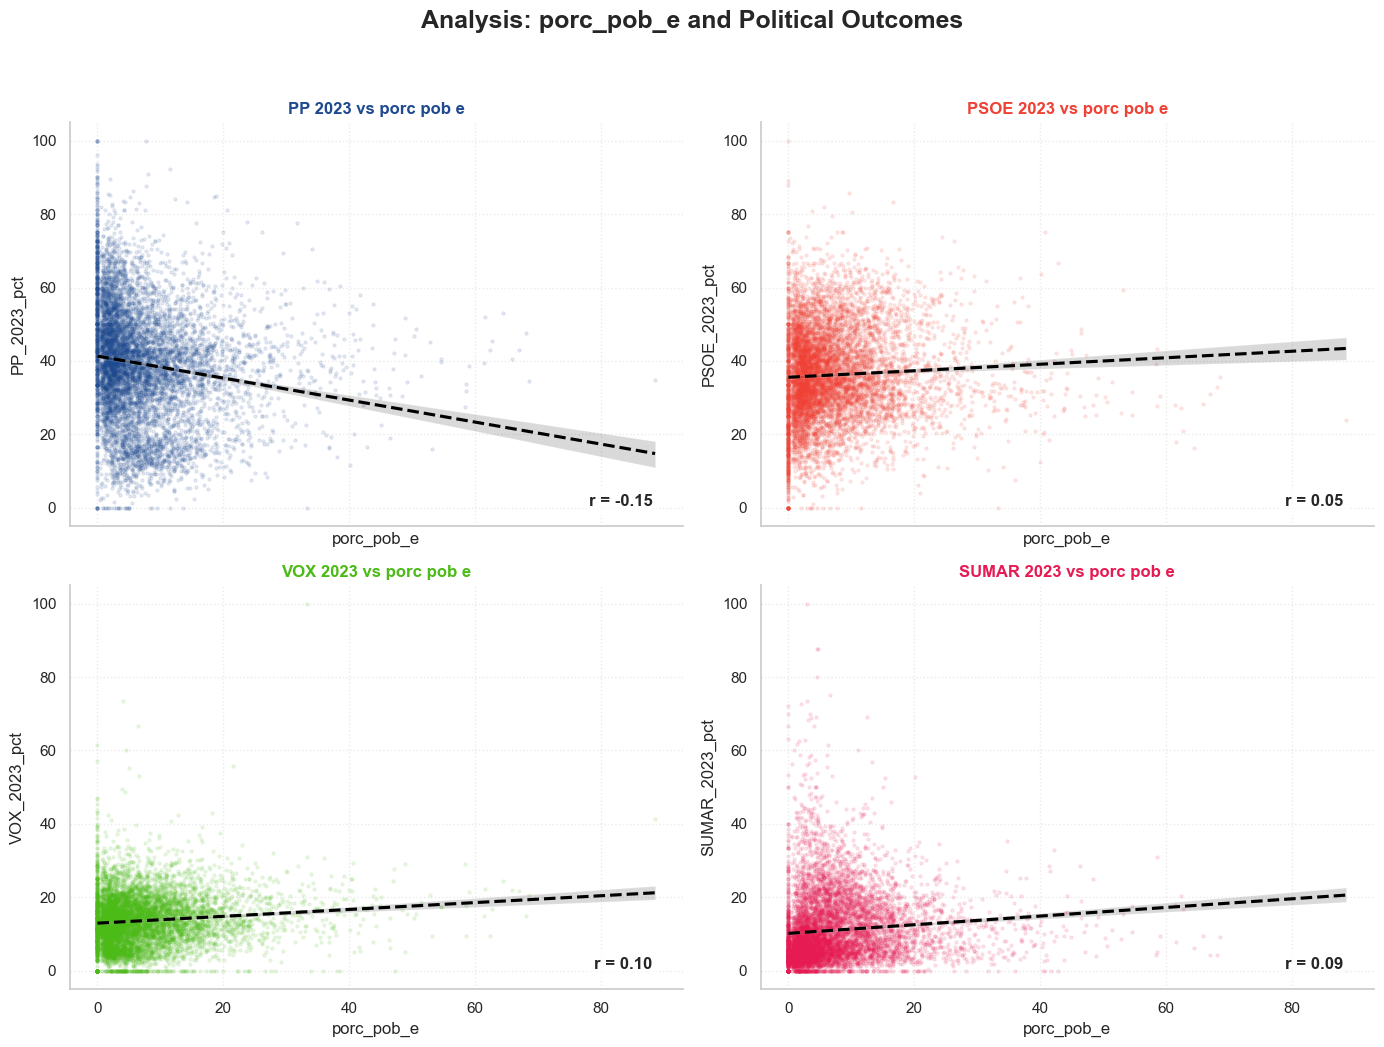

In [101]:
plot_party_comparison(gdf, target_col='porc_pob_e')

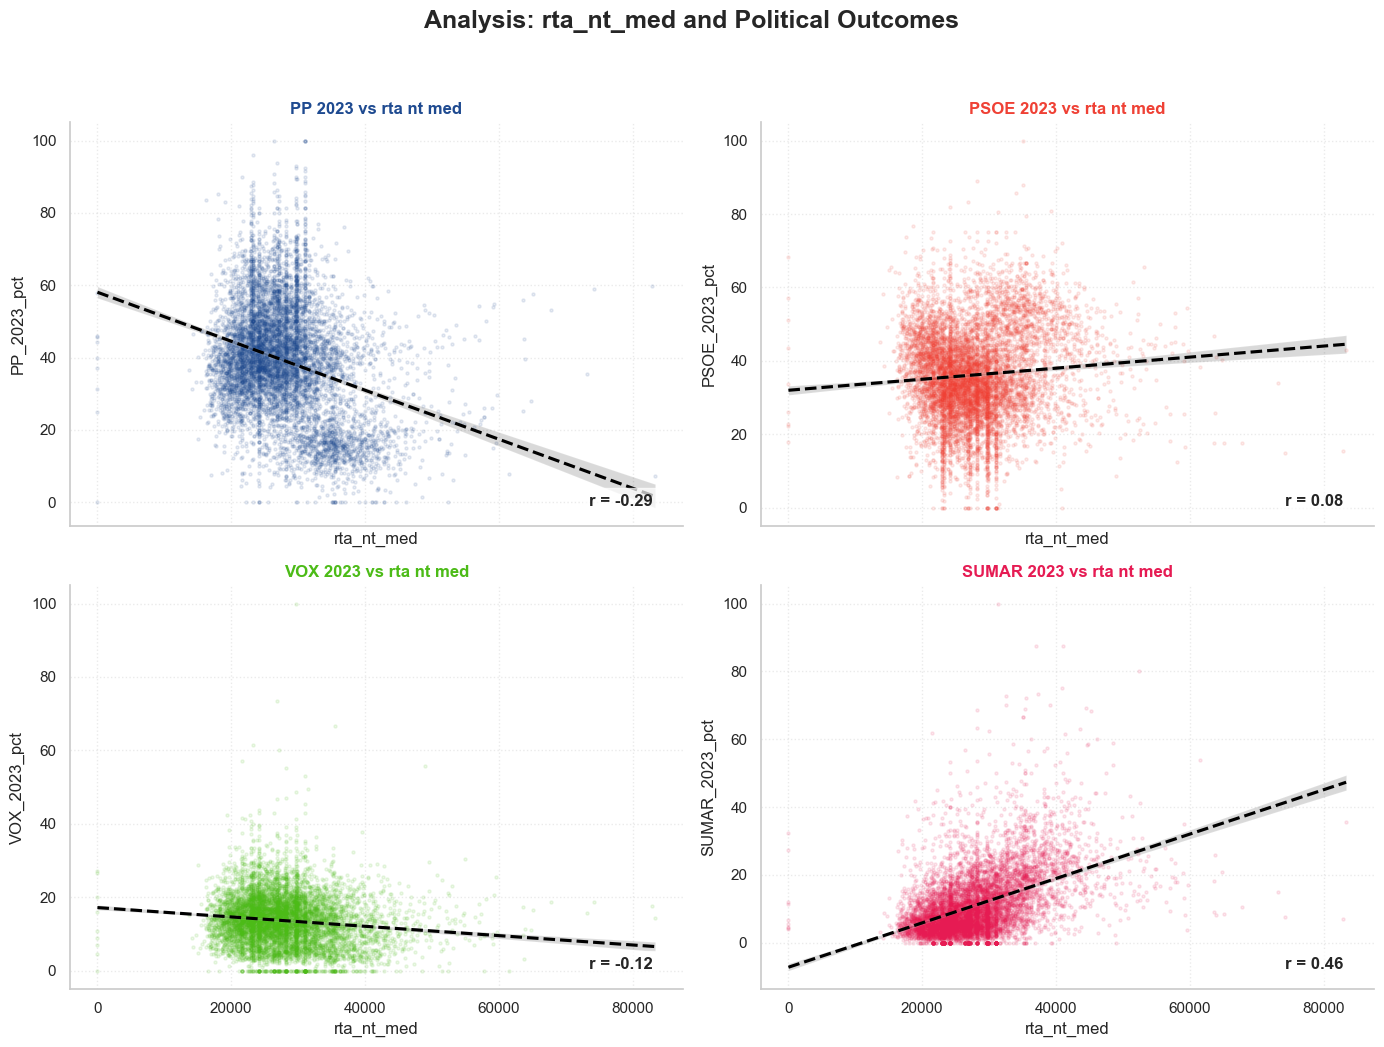

In [102]:
plot_party_comparison(gdf, target_col='rta_nt_med')

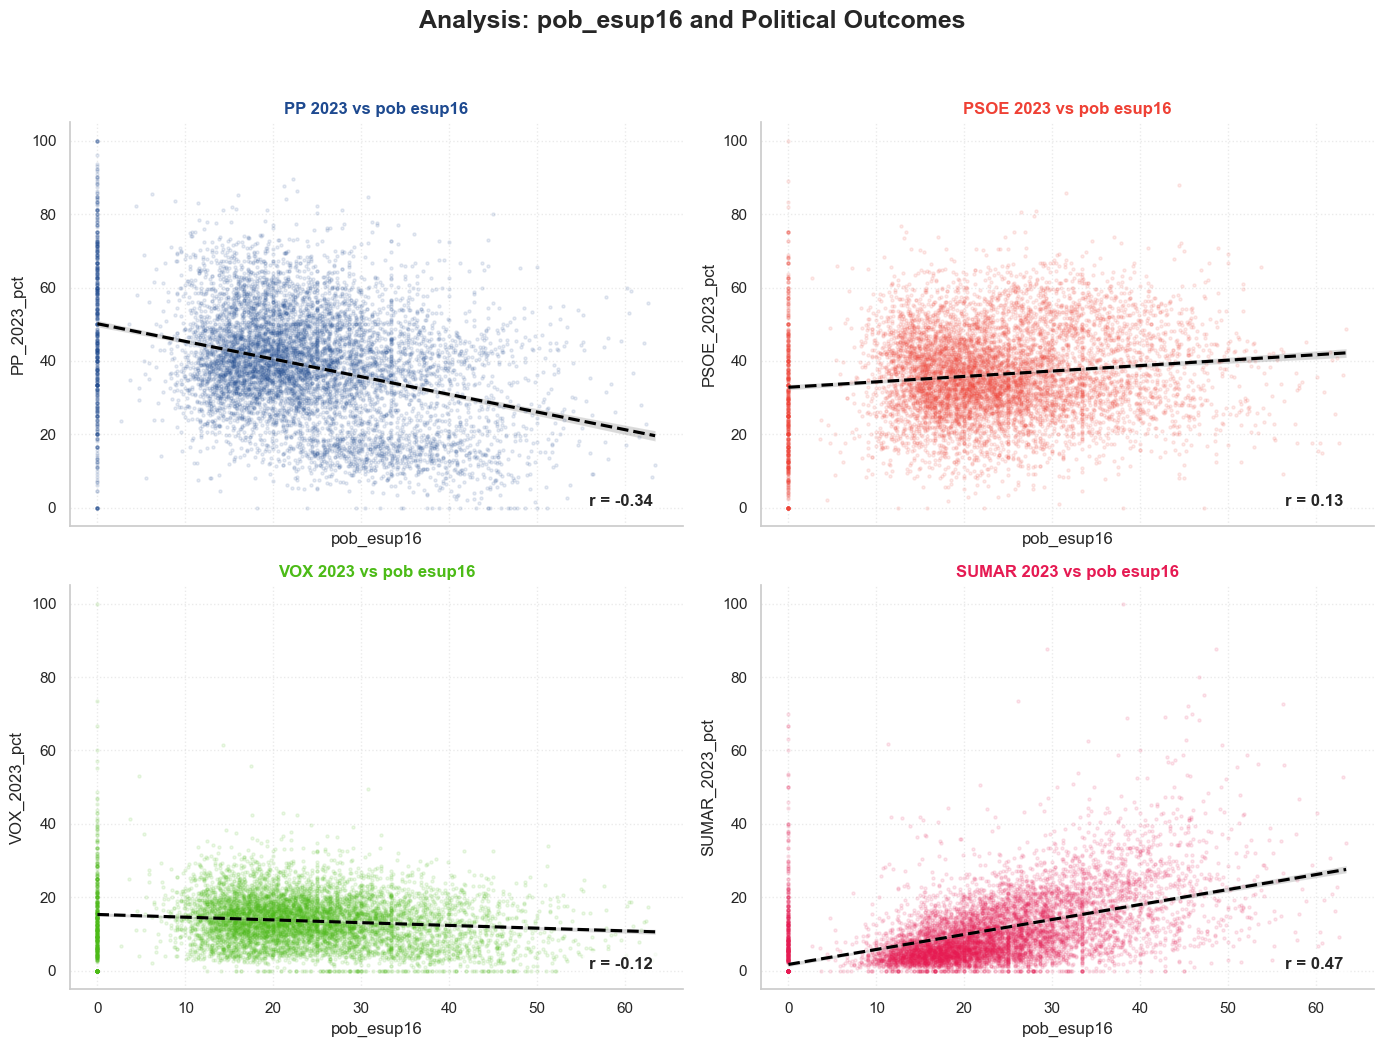

In [104]:
plot_party_comparison(gdf, target_col='pob_esup16')

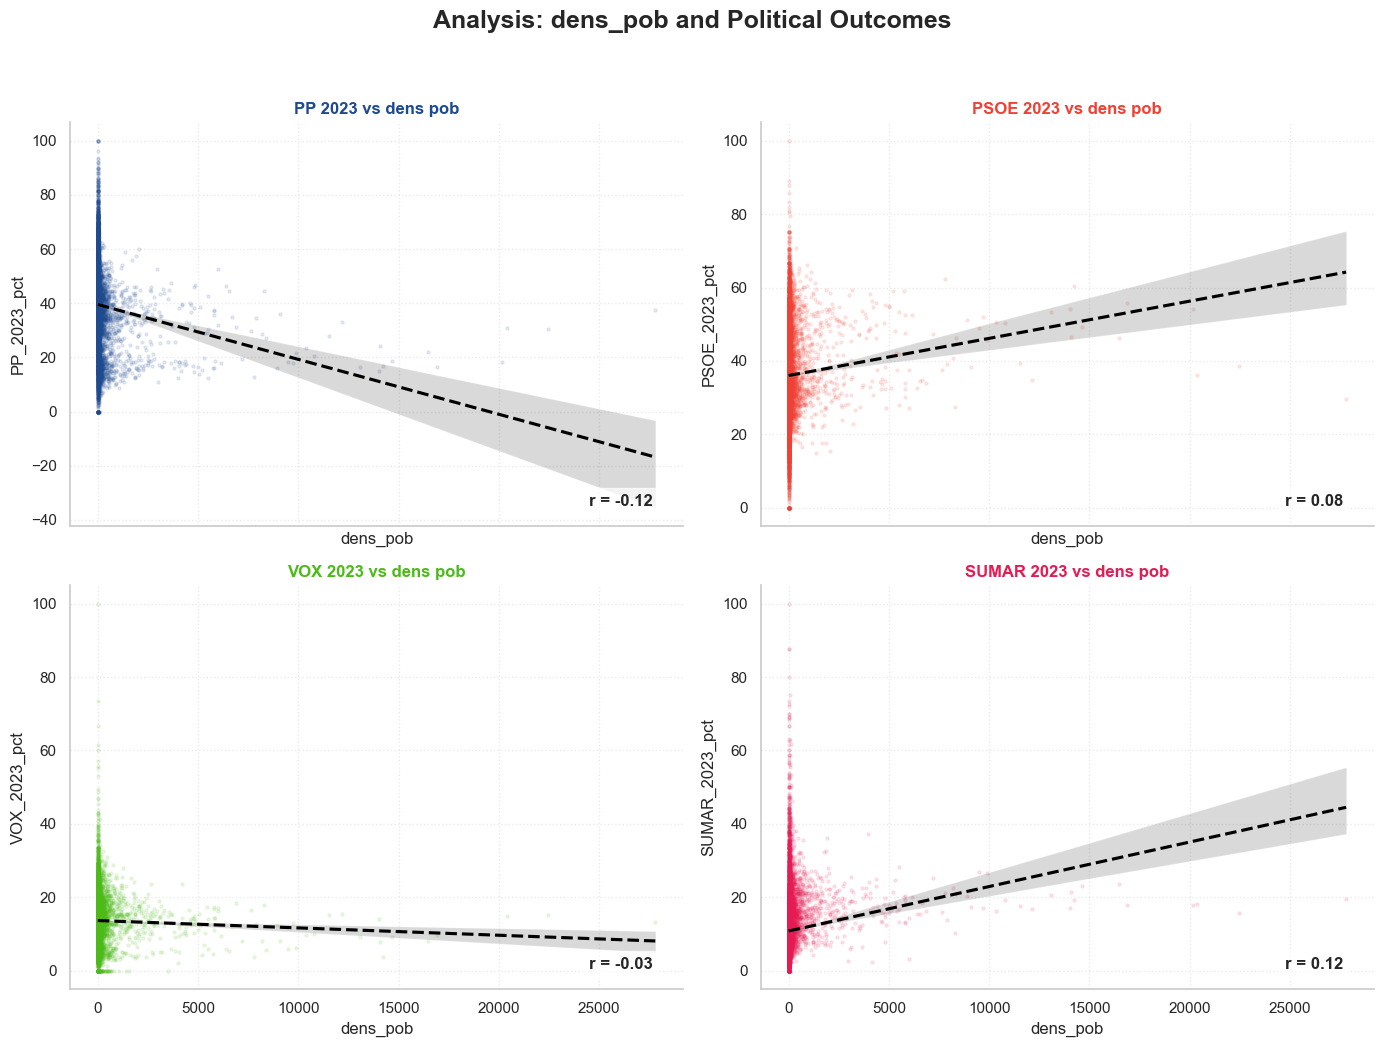

In [105]:
plot_party_comparison(gdf, target_col='dens_pob')

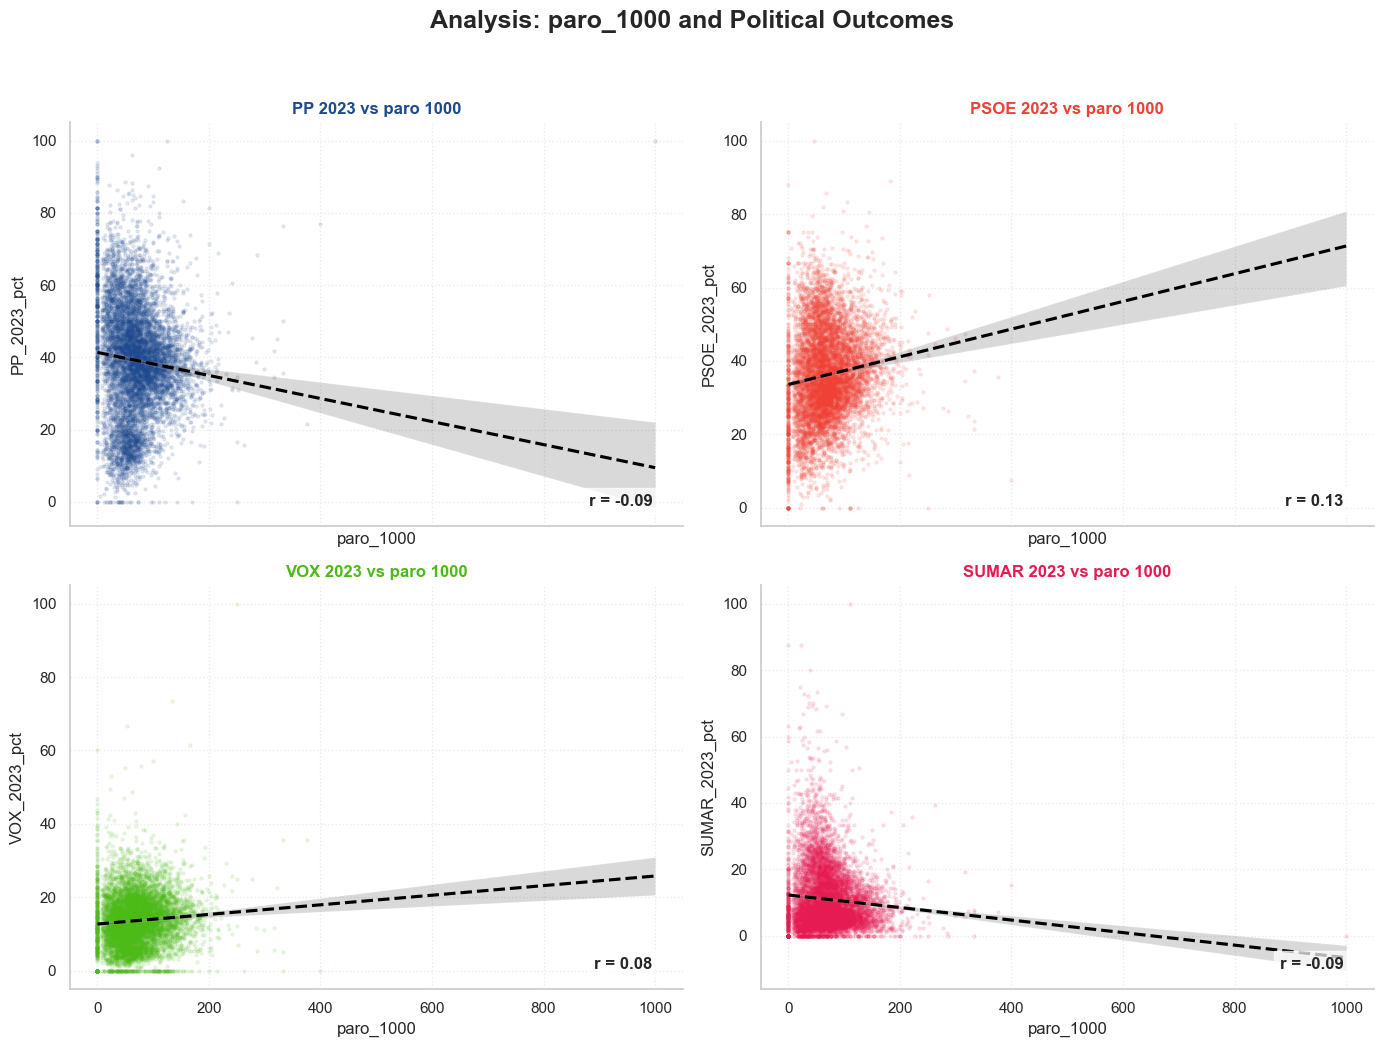

In [106]:
plot_party_comparison(gdf, target_col='paro_1000')